<h3 style = "color:green">Introduction

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">This Exploratory Data Analysis (EDA) project examines the Global YouTube Statistics 2023 dataset to uncover trends and patterns among the world's most influential YouTube channels. The analysis focuses on key metrics such as subscriber count, video views, uploads, earnings, channel categories, and geographical distribution. By exploring these variables through data cleaning, visualization, and statistical summaries, the project aims to provide insights into content creation trends, audience engagement, and the factors associated with channel popularity and growth on YouTube.

<h3 style = "color:green">Objective

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The primary objective of this project is to analyze the Global YouTube Statistics 2023 dataset and identify meaningful patterns in channel performance, content categories, and regional representation. Through exploratory data analysis, the project seeks to answer questions related to subscriber growth, viewership trends, content productivity, and the distribution of top-performing channels across different countries and niches.

In [2]:
import pandas as pd
import numpy as np
import polars as pl

from pandas import Series, DataFrame

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

<h3 style = "color:green">1. Getting ready with Data

In [3]:
data = pl.read_csv('/home/kartika/Datasets/Global YouTube Statistics.csv', encoding = 'latin1',ignore_errors = True)
data = data.to_pandas()

data.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000,2006.0,Mar,13.0,28.1,1366417754,5.36,471031528,20.593684,78.96288
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,nan,2006.0,Mar,5.0,88.2,328239523,14.7,270663028,37.09024,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000,2012.0,Feb,20.0,88.2,328239523,14.7,270663028,37.09024,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000,2006.0,Sep,1.0,88.2,328239523,14.7,270663028,37.09024,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000,2006.0,Sep,20.0,28.1,1366417754,5.36,471031528,20.593684,78.96288


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 995 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  995 non-null    object 
 8   Abbreviation                             995 non-null    object 
 9   channel_type                             995 non-null    object 
 10  video_views_rank                         994 non-n

<div style = "background-color:lightblue; color:green; font-size:20px">No null values.

In [5]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px">No duplicates values.

<div>

<div>

<h3 style = "color:green">2. Univariate Analysis

<h3 style = "color:green">2.1 Subscribers Distribution

In [6]:
data['subscribers'].describe()

count    9.950000e+02
mean     2.298241e+07
std      1.752611e+07
min      1.230000e+07
25%      1.450000e+07
50%      1.770000e+07
75%      2.460000e+07
max      2.450000e+08
Name: subscribers, dtype: float64

In [7]:
data['subscribers'].skew()

np.float64(5.513642744403962)

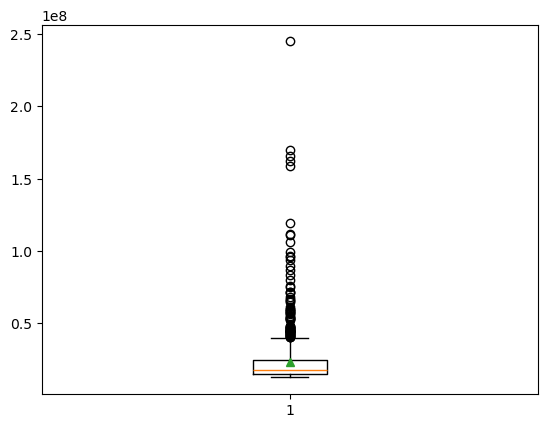

In [8]:
plt.boxplot(data['subscribers'], showmeans = True, )

plt.show()

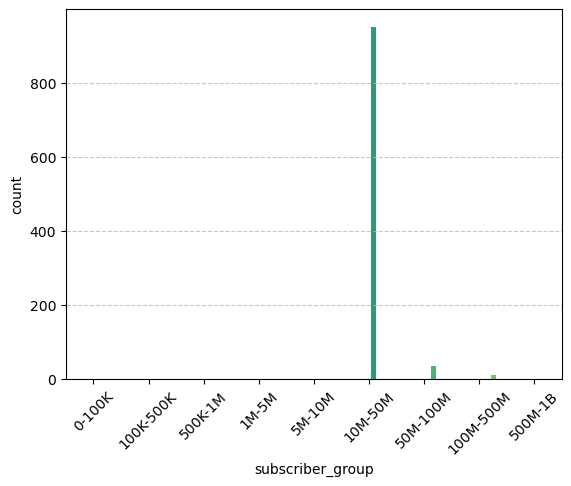

In [23]:
bins = [0, 100000, 500000, 1000000, 5000000,
        10000000, 50000000, 100000000,
        500000000, 1000000000]

labels = ['0-100K', '100K-500K', '500K-1M',
          '1M-5M', '5M-10M', '10M-50M',
          '50M-100M', '100M-500M', '500M-1B']

data['subscriber_group'] = pd.cut(
    data['subscribers'],
    bins=bins,
    labels=labels
)

sns.countplot(data=data, x='subscriber_group', hue = 'subscriber_group', palette = 'viridis')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.xticks(labels,rotation=45)
plt.show()

In [24]:
print(data['subscriber_group'].value_counts())

subscriber_group
10M-50M      951
50M-100M      35
100M-500M      9
0-100K         0
100K-500K      0
5M-10M         0
1M-5M          0
500K-1M        0
500M-1B        0
Name: count, dtype: int64


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">In top 1000 youtubers, 951 which is nearly 96% have subscribers between 10M-50M and rest 44 youtubers have subscribers >50M. Due to which the distribution is highly positively skewed, many youtubers have comparatively low subscribers, whereas top youtubers account for astronomical number of subscribers.